In [3]:
import numpy as np
import pandas as pd
from bitalg.tests.test2 import Test
import matplotlib.pyplot as plt
from bitalg.visualizer.main import Visualizer

In [4]:
def generate_uniform_points(left=-100, right=100, n=100):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym
    obszarze od left do right (jednakowo na osi y)
    o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
             np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    result = [None for _ in range(n)]
    for i in range(n):
        result[i] = (np.random.uniform(left, right), np.random.uniform(left, right))
    return result

In [5]:
def display_convex_hull(v,points,hull):
    v.clear()
    v.add_point(points)
    v.add_point(hull,color="red")
    v.add_line_segment([(hull[i], hull[i+1]) for i in range(len(hull)-1)],color="red")
    v.add_line_segment([hull[-1], hull[0]],color="red")
    v.show()

In [6]:
def det(a, b, c):
    """
    Obliczanie wyznacznika macierzy 2x2 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    return (a[0]-c[0])*(b[1]-c[1]) - (b[0]-c[0]) * (a[1]-c[1])

In [7]:
EPS = 10 **(-24)
def orient(a,b,c):
    r = det(a,b,c)
    if abs(r) < EPS:
        return 0
    elif r >0: return 1 
    else: return -1

In [8]:
def update_upper(hull, point):
    while True:
        if len(hull) >= 2 and orient(point, hull[-1], hull[-2]) <= 0:
            hull.pop()
        else:
            break

In [9]:
def update_lower(hull, point):
    while True:
        if len(hull) >= 2 and orient(point, hull[-1], hull[-2]) >= 0:
            hull.pop()
        else:
            break

In [10]:
def Incremental(Q):
    n = len(Q)
    if n < 3: return Q
    Q.sort()
    upper = [Q[0]]
    lower = [Q[0]]
    for i in range(1, n):
        update_upper(upper, Q[i])
        update_lower(lower, Q[i])
        upper.append(Q[i])
        lower.append(Q[i])
    return lower[:-1] + upper[1:][::-1]


In [11]:
def generate_uniform_points(left=-100, right=100, n=100):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym
    obszarze od left do right (jednakowo na osi y)
    o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
             np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    result = [None for _ in range(n)]
    for i in range(n):
        result[i] = (np.random.uniform(left, right), np.random.uniform(left, right))
    return result


In [12]:
def Incremental_vis(Q):
    blue = "#1f77b4"
    def update_upper(hull, point):
        v.add_point(point, color='purple')
        while True:
            if len(hull) >= 2 and orient(point, hull[-1], hull[-2]) < 0:
                v.add_point(hull.pop(), color=blue)
                v.remove_figure(u_edges.pop())
            else:
                
                break

    def update_lower(hull, point):
        while True:
            if len(hull) >= 2 and orient(point, hull[-1], hull[-2]) > 0:
                v.add_point(hull.pop(), color=blue)
                v.remove_figure(l_edges.pop())
            else:
                break

    v = Visualizer()
    v.add_point(Q, color=blue)

    n = len(Q)
    Q.sort()
    upper = [Q[0]]
    lower = [Q[0]]
    u_edges = []
    l_edges = []
    v.add_point(Q[0], color='green')
    for i in range(1, n):
        update_upper(upper, Q[i])
        update_lower(lower, Q[i])
        v.add_point(upper[1:], color='red')
        v.add_point(lower, color='green')
        upper.append(Q[i])
        lower.append(Q[i])
        u_edges.append(v.add_line_segment([upper[-2], upper[-1]], color='red'))
        l_edges.append(v.add_line_segment([lower[-2], lower[-1]], color='green'))
    return lower[:-1] + upper[1:][::-1], v
    

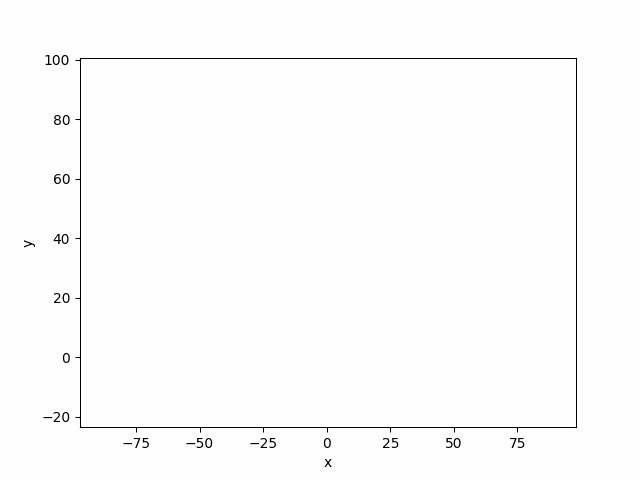

In [13]:
x = generate_uniform_points(-100, 100, 10)
hull, v = Incremental_vis(x)
v.show_gif()

In [189]:
Test().runtest(1, Incremental)


Lab 2, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: Passed
Result: 11/11
Time: 0.617s
